In [7]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize
import subprocess
Dir_working = r'Z:\study\phd\project\Semantics\Dissemination\table_figure'
Dir_github = r'Z:\study\phd\project\Semantics\FactorAnalysis\github'
repo = 'FactorAnalysis_fMRI'
# path_wb = r'D:\Software\fmri\workbench\bin_windows64'
# path_wb_atlas = r'D:\Software\fmri\workbench\atlas'
path_wb = r'Z:\Software\workbench\bin_windows64'
path_wb_atlas = r'Z:\Software\workbench\atlas'

In [8]:
### read template .txt file to be edited ###
file_template = os.path.join(path_wb_atlas,'Q1-Q6_RelatedValidation210.CorticalAreas_dil_Final_Final_Areas_Group_Colors.32k_fs_LR.dlabel.txt')
lines_label = []
lines_rgb = []
with open(file_template, 'r') as f:
    for i, line in enumerate(f):
        if i % 2 == 0:
            lines_label.append(line.strip())  # Remove newline and extra spaces
        else:
            lines_rgb.append(line.strip())  # Remove newline and extra spaces
df_txt = pd.DataFrame({'label':lines_label,'raw':lines_rgb})
df_txt[['idx','r','g','b','alpha']] = df_txt['raw'].str.split(' ',expand=True)
f.close()
df_txt['rgb'] = df_txt['r'].astype(str) + ' ' + df_txt['g'].astype(str) + ' ' +  df_txt['b'].astype(str)
df_txt

,label,raw,idx,r,g,b,alpha,rgb
0,R_V1_ROI,1 76 5 255 255,1,76,5,255,255,76 5 255
1,R_MST_ROI,2 52 108 132 255,2,52,108,132,255,52 108 132
2,R_V6_ROI,3 67 94 171 255,3,67,94,171,255,67 94 171
3,R_V2_ROI,4 26 54 239 255,4,26,54,239,255,26 54 239
4,R_V3_ROI,5 18 32 240 255,5,18,32,240,255,18 32 240
...,...,...,...,...,...,...,...,...
355,L_STSva_ROI,356 25 31 18 255,356,25,31,18,255,25 31 18
356,L_TE1m_ROI,357 67 48 49 255,357,67,48,49,255,67 48 49
357,L_PI_ROI,358 122 53 50 255,358,122,53,50,255,122 53 50
358,L_a32pr_ROI,359 128 66 86 255,359,128,66,86,255,128 66 86


In [9]:
df_results = pd.read_csv(os.path.join(Dir_github,repo,'data','HCPex_p005FDR','df_ROIvalue_HCPex_p005FDR_unsmoothed.csv'))
df_results = df_results.loc[df_results['ROI_idx']!=0]
df_results = df_results.loc[~df_results['Cortical Division'].isna()]
df_results['LR'] = df_results['LR'].str.replace('idx_','')
df_results['label'] = df_results['LR']+'_'+df_results['Region']+'_ROI'
df_results['label'] = df_results['label'].str.replace(' ','')
dict_recode = {'L_7Pl_ROI':'L_7PL_ROI',
               'R_7Pl_ROI':'R_7PL_ROI'}

for old in dict_recode.keys():
    df_results.loc[df_results['label']==old,'label'] = dict_recode[old]
df_results['label_new'] = df_results['label'].str.replace('_ROI','').str.replace('L_','').str.replace('R_','')

In [36]:
df_results.loc[df_results['label'].str.contains('R_STV')]

,iFA,ROI_idx,ROI_value,significant,alpha,label,p_value,alpha_FDR,p_value_FDR,significant_FDR,...,Region,RegionLongName,Cortical Division,Cortex,Original,Voxel numbers,LR,idx,#No.,label_new
277,1,277.0,3.732016,1,0.001,R_STV_ROI,9.497686e-05,0.005,0.001753,1,...,STV,Superior_Temporal_Visual_Area,TPO,15.0,28.0,"2322, 2294",R,277.0,277.0,STV
683,2,277.0,-5.370775,1,0.001,R_STV_ROI,3.919944e-08,0.005,0.000002,1,...,STV,Superior_Temporal_Visual_Area,TPO,15.0,28.0,"2322, 2294",R,277.0,277.0,STV
1089,3,277.0,-3.391603,1,0.001,R_STV_ROI,3.474258e-04,0.005,0.004864,1,...,STV,Superior_Temporal_Visual_Area,TPO,15.0,28.0,"2322, 2294",R,277.0,277.0,STV
1495,4,277.0,4.535409,1,0.001,R_STV_ROI,2.874592e-06,0.005,0.000195,1,...,STV,Superior_Temporal_Visual_Area,TPO,15.0,28.0,"2322, 2294",R,277.0,277.0,STV
1901,5,277.0,-1.285268,0,0.001,R_STV_ROI,9.934931e-02,0.005,0.220414,0,...,STV,Superior_Temporal_Visual_Area,TPO,15.0,28.0,"2322, 2294",R,277.0,277.0,STV
2307,6,277.0,3.609640,1,0.001,R_STV_ROI,1.533113e-04,0.005,0.000635,1,...,STV,Superior_Temporal_Visual_Area,TPO,15.0,28.0,"2322, 2294",R,277.0,277.0,STV
2713,7,277.0,2.878073,0,0.001,R_STV_ROI,2.000560e-03,0.005,0.020172,0,...,STV,Superior_Temporal_Visual_Area,TPO,15.0,28.0,"2322, 2294",R,277.0,277.0,STV
3119,8,277.0,-4.223757,1,0.001,R_STV_ROI,1.201314e-05,0.005,0.000542,1,...,STV,Superior_Temporal_Visual_Area,TPO,15.0,28.0,"2322, 2294",R,277.0,277.0,STV


In [34]:
df_freq = df_results.groupby(['label','ROI_idx']).sum(numeric_only=True)
df_freq.loc[df_freq['significant_FDR']==6]

,,iFA,ROI_value,significant,alpha,p_value,alpha_FDR,p_value_FDR,significant_FDR,Cortex,Original,idx,#No.
label,ROI_idx,,,,,,,,,,,,
R_STSdp_ROI,244.0,36,-7.050878,6,0.008,0.632063,0.04,0.807448,6,88.0,1032.0,1952.0,1952.0
R_STV_ROI,277.0,36,0.483735,6,0.008,0.101961,0.04,0.248577,6,120.0,224.0,2216.0,2216.0


In [10]:
df_results['ROI_value'].min(),df_results['ROI_value'].max()

(-8.817713737487793, 9.05300998687744)

In [11]:
import re
def make_annot(file_annot,List_region_hide,path_txtOutput):
    with open(file_annot, "r", encoding="utf-8") as f:
        text = f.read()

    # Split by <MetaData/>
    string_sep = "            <MetaData/>\n        "
    df_annot = pd.DataFrame({'text':text.split(string_sep)})

    # get region name
    pattern = r'(?<=connectBrainordinate="ANNOTATION_TEXT_CONNECT_NONE">)(.*?)(?=</textData>)'
    df_annot["region"] = df_annot["text"].apply(
        lambda x: (m.group(1).strip() if (m := re.search(pattern, x)) else '')
    )
    df_annot['text'] = df_annot['text'].str.replace('<textData textCaretColor="WHITE"','<textData textCaretColor="BLACK"')

    # get unique key index and assign LR label
    pattern = r'uniqueKey="(\d+)"'
    df_annot["uniqueKey"] = df_annot["text"].apply(
        lambda x: (m.group(1).strip() if (m := re.search(pattern, x)) else '')
    )
    df_annot["LR"] = df_annot["region"].duplicated(keep="first").map({False: "L", True: "R"})
    df_annot['label_annot'] = df_annot["LR"]+'_' +df_annot["region"]

    # hide the labels
    # df_output['label_annot'] = df_output['label'].str.replace('_ROI','')
    # List_region_hide = df_output.loc[df_output['alpha']==0,'label_annot'].tolist()
    pattern = r'(?<=connectBrainordinate="ANNOTATION_TEXT_CONNECT_NONE">)(.*?)(?=</textData>)'

    for i, row in df_annot.iterrows():
        if row['label_annot'] in List_region_hide:
            df_annot.loc[i,'text'] = re.sub(pattern, " ", df_annot.loc[i,'text'])


    new_text = string_sep.join(df_annot["text"].tolist())

    # path_txtOutput = os.path.join(Dir_output,f'{file}.wb_annot')
    # Save the modified file
    with open(path_txtOutput, "w", encoding="utf-8") as f:
        f.write(new_text)

def make_output_txt(df_output,path_txtOutput):
        
    with open(path_txtOutput, 'w') as f:
        for i,row in df_output.iterrows():
            line = row['label']
            f.write(line + '\n')  # Add newline character explicitly

            line = f"{row['idx']} {row['rgb']} {row['alpha']}"
            f.write(line + '\n')  # Add newline character explicitly

In [38]:
Dir_output = r'Z:\study\phd\project\Semantics\Dissemination\table_figure'
file_annot = r'D:\Software\fmri\workbench\atlas\template_annot.wb_annot'

norm = Normalize(vmin=df_results['ROI_value'].min(),vmax=df_results['ROI_value'].max())
cmap = cm.get_cmap('coolwarm')  # Or 'coolwarm' for smoother gradation

for iFA in range(1,8+1):
    df_output = pd.merge(left = df_txt,left_on='label',
         right=df_results.loc[df_results['iFA']==iFA,['label','ROI_value','p_value_FDR','significant_FDR']],right_on='label',how='left')
    # Get RGB values
    rgb_colors = [cmap(norm(v))[:3] for v in df_output['ROI_value']]  # Only RGB, drop alpha
    rgb_colors_255 = [f"{int(r*255)} {int(g*255)} {int(b*255)}" for (r, g, b) in rgb_colors]
    df_output[f'rgb'] = rgb_colors_255
    # df_output.loc[df_output['p_value_FDR']<.005,'alpha'] = 255
    # df_output.loc[df_output['p_value_FDR']>=.005,'alpha'] = 0
    df_output.loc[df_output['significant_FDR']==1,'alpha'] = 255
    df_output.loc[df_output['significant_FDR']==0,'alpha'] = 0

    file = f'figure_parcel_p005FDR_FA{iFA}_unsmoothed'        
    path_txtOutput = os.path.join(Dir_output,f'{file}.txt')
    path_annotOutput = os.path.join(Dir_output,f'{file}.wb_annot')
    img_output = os.path.join(Dir_output,f'{file}.dlabel.nii')
    img_input = os.path.join(path_wb_atlas,'Q1-Q6_RelatedValidation210.CorticalAreas_dil_Final_Final_Areas_Group_Colors.32k_fs_LR.dlabel.nii')
    make_output_txt(df_output,path_txtOutput)

    df_output['label_annot'] = df_output['label'].str.replace('_ROI','')
    List_region_hide = df_output.loc[df_output['alpha']==0,'label_annot'].tolist()
    make_annot(file_annot,List_region_hide,path_annotOutput)


    cmd = f'{path_wb}\wb_command -cifti-label-import {img_input} {path_txtOutput} {img_output}'
    subprocess.run(cmd, check=True)
    

C:\Users\XuanR\AppData\Local\Temp\ipykernel_9768\2681193633.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('coolwarm')  # Or 'coolwarm' for smoother gradation


In [ ]:
Dir_output = r'Z:\study\phd\project\Semantics\Dissemination\table_figure'
file_annot = r'D:\Software\fmri\workbench\atlas\template_annot.wb_annot'

norm = Normalize(vmin=df_results['ROI_value'].min(),vmax=df_results['ROI_value'].max())
cmap = cm.get_cmap('coolwarm')  # Or 'coolwarm' for smoother gradation

for iFA in range(1,8+1):
    df_output = pd.merge(left = df_txt,left_on='label',
         right=df_results.loc[df_results['iFA']==iFA,['label','ROI_value','p_value_FDR','significant_FDR']],right_on='label',how='left')
    # Get RGB values
    rgb_colors = [cmap(norm(v))[:3] for v in df_output['ROI_value']]  # Only RGB, drop alpha
    rgb_colors_255 = [f"{int(r*255)} {int(g*255)} {int(b*255)}" for (r, g, b) in rgb_colors]
    df_output[f'rgb'] = rgb_colors_255
    # df_output.loc[df_output['p_value_FDR']<.005,'alpha'] = 255
    # df_output.loc[df_output['p_value_FDR']>=.005,'alpha'] = 0
    # df_output.loc[df_output['significant_FDR']==1,'alpha'] = 255
    # df_output.loc[df_output['significant_FDR']==0,'alpha'] = 0
    
    file = f'figure_parcel_p005FDR_FA{iFA}_unsmoothed'        
    path_txtOutput = os.path.join(Dir_output,f'{file}.txt')
    path_annotOutput = os.path.join(Dir_output,f'{file}.wb_annot')
    img_output = os.path.join(Dir_output,f'{file}.dlabel.nii')
    img_input = os.path.join(path_wb_atlas,'Q1-Q6_RelatedValidation210.CorticalAreas_dil_Final_Final_Areas_Group_Colors.32k_fs_LR.dlabel.nii')
    make_output_txt(df_output,path_txtOutput)

    df_output['label_annot'] = df_output['label'].str.replace('_ROI','')
    List_region_hide = df_output.loc[df_output['alpha']==0,'label_annot'].tolist()
    make_annot(file_annot,List_region_hide,path_annotOutput)


    cmd = f'{path_wb}\wb_command -cifti-label-import {img_input} {path_txtOutput} {img_output}'
    subprocess.run(cmd, check=True)
    

In [14]:
df_output.loc[df_output['label'].str.contains('45')]

,label,raw,idx,r,g,b,alpha,rgb,ROI_value,p_value_FDR,label_annot
74,R_45_ROI,75 83 62 56 255,75,83,62,56,0,241 202 182,1.878432,0.096857,R_45
254,L_45_ROI,255 46 64 41 255,255,46,64,41,255,246 187 160,2.887269,0.017891,L_45


C:\Users\XuanR\AppData\Local\Temp\ipykernel_42320\2431721707.py:31: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap_orig = plt.cm.get_cmap("coolwarm_r", 1024)


[]

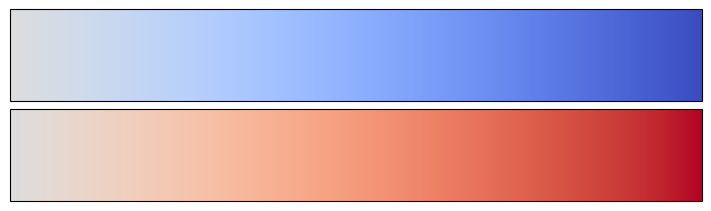

In [26]:
# Standalone script (no function) to generate TWO split colorbars from coolwarm_r.
# - Top:  vmin_global --> midpoint (uses coolwarm_r sampled midpoint -> blue)
# - Bottom: midpoint --> vmax_global (uses coolwarm_r sampled midpoint -> red)
# The exact midpoint color is identical in both bars.
#
# Assumes `df_results` (with column 'ROI_value') and `Dir_output` are already defined
# in the environment where you run this script.

import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import ListedColormap, Normalize

# --- Inputs (these must exist in your environment) ---
# df_results  # pandas DataFrame with column 'ROI_value'
# Dir_output  # string path to save images

# --- Compute global min/max and midpoint (change mid if you want another center) ---
vmin_global = float(df_results['ROI_value'].min())
vmax_global = float(df_results['ROI_value'].max())
mid = 0.0  # change if you want a different center

# --- Safety: ensure ranges are sensible (vmin < mid < vmax) ---
if vmin_global >= mid:
    vmin_global = mid - max(1.0, abs(mid) * 0.1)
if vmax_global <= mid:
    vmax_global = mid + max(1.0, abs(mid) * 0.1)

# --- Sample the original coolwarm_r colormap densely ---
cmap_orig = plt.cm.get_cmap("coolwarm_r", 1024)

# positions in original cmap: 0..1 where 0.5 is the midpoint color
# We create two arrays of positions that start at 0.5 (midpoint color)
# and go outwards to the two ends of the original palette.
n_samples = 256
pos_positions = np.linspace(0.5, 0.0, n_samples)  # midpoint -> original high end (red in coolwarm_r)
neg_positions = np.linspace(0.5, 1.0, n_samples)  # midpoint -> original low  end (blue in coolwarm_r)

# sample RGB colors (drop alpha)
pos_colors = cmap_orig(pos_positions)[:, :3]  # midpoint -> red
neg_colors = cmap_orig(neg_positions)[:, :3]  # midpoint -> blue

# create half-colormaps preserving the original palette look
cmap_pos = ListedColormap(pos_colors, name="half_pos_coolwarm_r")
cmap_neg = ListedColormap(neg_colors, name="half_neg_coolwarm_r")

# --- Normalizers for each half (vmin must be < vmax) ---
norm_neg = Normalize(vmin=vmin_global, vmax=mid)   # maps vmin..mid -> 0..1
norm_pos = Normalize(vmin=mid, vmax=vmax_global)   # maps mid..vmax -> 0..1

# --- Build and save the stacked horizontal colorbars ---
fig, axes = plt.subplots(2, 1, figsize=(7, 2), constrained_layout=True)

# top: negative side (vmin -> mid) using midpoint->blue ramp
sm_neg = ScalarMappable(norm=norm_neg, cmap=cmap_neg)
sm_neg.set_array([])
cbar_neg = fig.colorbar(sm_neg, cax=axes[0], orientation='horizontal')
# cbar_neg.set_label(f"Negative ({vmin_global:.3g} → {mid:.3g})", fontsize=9)
cbar_neg.set_ticks(np.linspace(vmin_global, mid, 5))
cbar_neg.ax.tick_params(labelsize=8)

cbar_neg.set_ticks([])
cbar_neg.ax.set_xticks([])

# bottom: positive side (mid -> vmax) using midpoint->red ramp
sm_pos = ScalarMappable(norm=norm_pos, cmap=cmap_pos)
sm_pos.set_array([])
cbar_pos = fig.colorbar(sm_pos, cax=axes[1], orientation='horizontal')
# cbar_pos.set_label(f"Positive ({mid:.3g} → {vmax_global:.3g})", fontsize=9)
# cbar_pos.set_ticks(np.linspace(mid, vmax_global, 5))
cbar_pos.ax.tick_params(labelsize=8)
cbar_pos.set_ticks([])
cbar_pos.ax.set_xticks([])
# # --- Save outputs (PNG + SVG) ---
# os.makedirs(Dir_output, exist_ok=True)
# png_path = os.path.join(Dir_output, "split_coolwarm_r_colorbars.png")
# svg_path = os.path.join(Dir_output, "split_coolwarm_r_colorbars.svg")
# fig.savefig(png_path, dpi=300, bbox_inches="tight")
# fig.savefig(svg_path, format="svg", bbox_inches="tight")
# plt.close(fig)

# print("Saved colorbars to:", png_path, svg_path)


(-8.82, 9.05)

-8.82 9.05


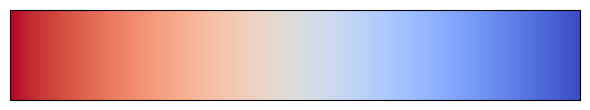

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable

vmin = df_results['ROI_value'].min()
vmax = df_results['ROI_value'].max()

# Ensure norm and cmap defined as in your main script
# norm = Normalize(vmin=vmin, vmax=vmax)
# cmap = cm.get_cmap('coolwarm_r')

sm = ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

fig, ax = plt.subplots(figsize=(6, 1.2))
cbar = fig.colorbar(sm, cax=ax, orientation='horizontal')
# cbar.set_label('ROI value', fontsize=10)

ticks = np.linspace(vmin, vmax, 5)
cbar.set_ticks(ticks)
cbar.set_ticklabels([f'{t:.2f}' for t in ticks])
cbar.set_ticks([])
cbar.ax.set_xticks([])
plt.tight_layout()

fig.savefig(os.path.join(Dir_output, 'colorbar_horizontal.png'),
            dpi=300, bbox_inches='tight')
# plt.close(fig)
print(round(vmin,2),round(vmax,2))

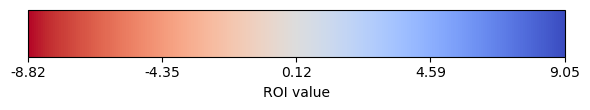

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable


vmin = df_results['ROI_value'].min()
vmax = df_results['ROI_value'].max()

# scalar mappable to use the same norm and cmap as your parcels
sm = ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

fig, ax = plt.subplots(figsize=(6, 1.2))
cbar = fig.colorbar(sm, cax=ax, orientation='horizontal', fraction=0.8, pad=0.3)
cbar.set_label('ROI value', fontsize=10)
# nice tick choices
ticks = np.linspace(vmin, vmax, 5)
cbar.set_ticks(ticks)
cbar.set_ticklabels([f'{t:.2f}' for t in ticks])

plt.tight_layout()
# fig.savefig(os.path.join(Dir_output, 'colorbar_horizontal.png'), dpi=300, bbox_inches='tight')
# plt.close(fig)


delete

In [ ]:
from sklearn.manifold import MDS
from sklearn.metrics.pairwise import euclidean_distances
df_results_wide = df_results.pivot(index=['label','LR','RegionLongName','label_new','idx'],columns=['iFA'],values='ROI_value',).reset_index()
df_results_wide_p = df_results.pivot(index=['label','LR','RegionLongName','label_new','idx'],columns=['iFA'],values='p_value_FDR',)
List_roi_colors = ['160-L_45_ROI','244-R_STSdp_ROI','125-L_7m_ROI','88-L_PHT_ROI']
# 
for roi in List_roi_colors:
        
    vec0 = df_results_wide.loc[df_results_wide['label']==roi.split('-')[1],[1,2,3,4,5,6,7,8]].values[0]
    for i, row in df_results_wide.iterrows():
        vec = row[[1,2,3,4,5,6,7,8]].values
        euclidean_obs = np.linalg.norm(vec0 - vec)
        df_results_wide.loc[i,roi] = euclidean_obs

df_results_wide['count_sig'] = (df_results_wide_p<.05).sum(axis=1).values
X = df_results_wide[[1,2,3,4,5,6,7,8]].values

In [339]:
# Rotation function
def rotate_2d(X, angle):
    theta = np.radians(angle)  # Convert angle to radians
    rotation_matrix = np.array([[np.cos(theta), -np.sin(theta)], 
                                [np.sin(theta), np.cos(theta)]])
    return X @ rotation_matrix.T  # Apply rotation

distance_matrix = euclidean_distances(X)

# Apply MDS (reducing to 2D)
mds = MDS(n_components=2, dissimilarity="precomputed", random_state=42)
X_mds = mds.fit_transform(distance_matrix)
X_rotated = rotate_2d(X_mds, angle=-120)


In [340]:
df_mds = pd.DataFrame(X_rotated,columns=['x1','x2'])
df_mds[['idx','label','LR','RegionLongName','label_new','count_sig']+List_roi_colors] = df_results_wide[['idx','label','LR','RegionLongName','label_new','count_sig']+List_roi_colors]
df_mds

,x1,x2,idx,label,LR,RegionLongName,label_new,count_sig,160-L_45_ROI,244-R_STSdp_ROI,125-L_7m_ROI,88-L_PHT_ROI
0,2.928220,-2.250205,150.0,L_10d_ROI,L,Area_10d,10d,2,8.099599,14.047014,9.260585,13.054000
1,0.223262,-1.582627,151.0,L_10pp_ROI,L,Polar_10p,10pp,2,9.627857,15.315879,9.495803,12.579577
2,0.214177,-4.737357,134.0,L_10r_ROI,L,Area_10r,10r,2,9.081635,14.031785,7.363780,13.829824
3,1.552288,-4.986393,135.0,L_10v_ROI,L,Area_10v,10v,2,8.428823,13.268874,7.685708,14.145122
4,-0.103972,1.291323,152.0,L_11l_ROI,L,Area_11l,11l,1,10.097494,16.583536,10.936222,8.807016
...,...,...,...,...,...,...,...,...,...,...,...,...
355,-0.537418,1.582630,358.0,R_p9-46v_ROI,R,Area_posterior_9-46v,p9-46v,1,9.862111,16.104144,8.569710,10.340058
356,2.827057,1.141861,328.0,R_pOFC_ROI,R,Posterior_OFC_Complex,pOFC,2,6.811133,12.483965,10.100695,11.233753
357,-2.468601,-4.673679,329.0,R_s32_ROI,R,Area_s32,s32,5,9.351052,14.293218,8.633997,12.898215
358,-2.683433,-3.337270,359.0,R_s6-8_ROI,R,Superior_6-8_Transitional_Area,s6-8,1,12.249207,16.996287,7.923798,12.080605


In [289]:

# 2) Axis-angle (Rodrigues) rotation
def axis_angle_rotation(axis, angle_rad):
    axis = np.asarray(axis, dtype=float)
    axis = axis / np.linalg.norm(axis)
    ux, uy, uz = axis
    c = np.cos(angle_rad)
    s = np.sin(angle_rad)
    C = 1 - c
    R = np.array([
        [c + ux*ux*C,    ux*uy*C - uz*s, ux*uz*C + uy*s],
        [uy*ux*C + uz*s, c + uy*uy*C,    uy*uz*C - ux*s],
        [uz*ux*C - uy*s, uz*uy*C + ux*s, c + uz*uz*C   ]
    ])
    return R

def rotate_colors(colors,coord,degree):
        
    # Choose a rotation matrix (pick one)
    # R = random_rotation_matrix(seed=1)
    # OR use axis-angle, e.g. rotate 45 degrees around (1,1,0)
    R = axis_angle_rotation(coord, np.deg2rad(degree))

    # Apply rotation
    rotated = colors.dot(R.T)   # shape (n,3)

    # --- Map rotated cloud back to [0,1] while preserving relationships ---
    # Option A: uniform linear map using global min/max (preserves distances up to scalar)
    min_all = rotated.min()
    max_all = rotated.max()
    if max_all - min_all == 0:
        scaled = np.clip(rotated - min_all, 0, 1)  # degenerate case
    else:
        scaled = (rotated - min_all) / (max_all - min_all)
    scaled = np.clip(scaled, 0, 1)  # safety

    # Now scaled is in [0,1] and can be used as colors
    colors_rotated_01 = scaled
    return(colors_rotated_01)

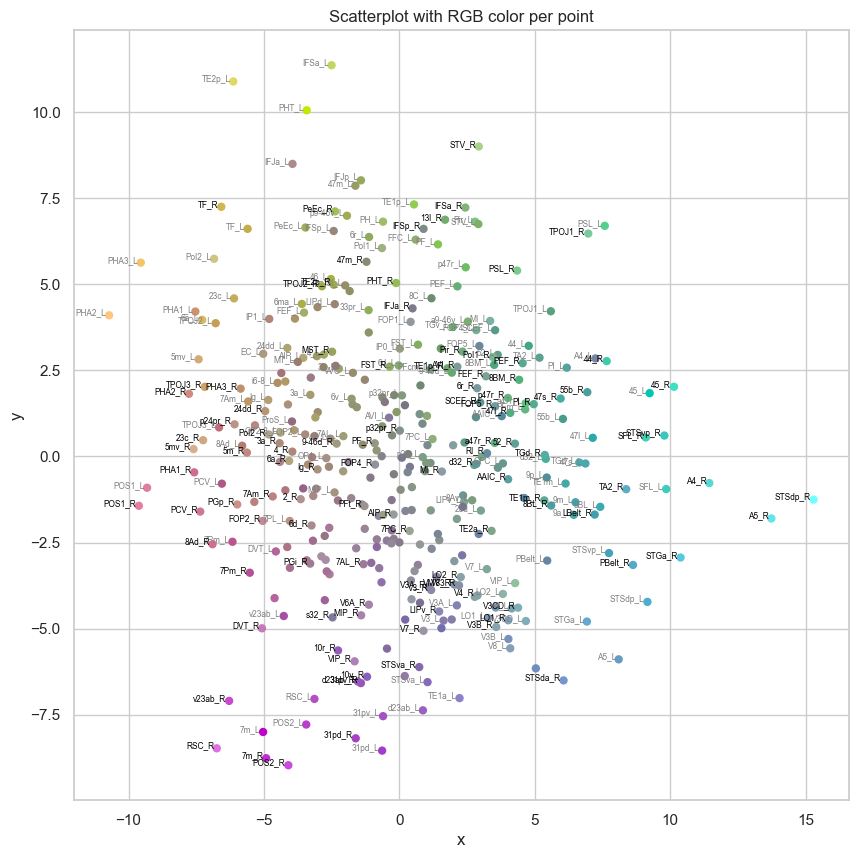

In [293]:
# df_plot = df_mds.loc[df_mds['LR']=='L'].copy()
df_plot = df_mds.copy()
# df_plot = df_mds.loc[df_mds['count_sig']>1].copy()
df_plot['group'] = 'other'

# Each point has its own A,B,C (values between 0–1)
A = df_plot['160-L_45_ROI'].values   # example red channel
B = df_plot['125-L_7m_ROI'].values  # example green channel
C = df_plot['88-L_PHT_ROI'].values   # example blue channel

# Normalize to 0–1 (if needed)
def norm01(v):
    v = np.asarray(v, dtype=float)
    v = v - v.min()
    if v.max() != 0:
        v = v / v.max()
    return np.clip(v, 0, 1)

A, B, C = norm01(A), norm01(B), norm01(C)

# Combine into Nx3 RGB array
colors = np.stack([A, B, C], axis=1)


fig,ax=plt.subplots(1,1,figsize=(10,10))


for i, row in df_plot.iterrows():
    if row['count_sig']>=3:
            
        x=row['x1']-0.1
        y=row['x2']
        i = row['label_new']+'_'+row['LR']
        font_color = 'gray' if row['LR'] == 'L' else 'black'
        ax.text(x, y, str(i), fontsize=6, ha='right',color=font_color)

# Get current axes and recolor points
ax.scatter(df_plot['x1'], df_plot['x2'], color=colors, s=25, edgecolor=None, )#linewidth=0.3)

ax.set_title("Scatterplot with RGB color per point")
ax.set_xlabel("x")
ax.set_ylabel("y")
plt.show()


restart 0: success=True, fun=-42.877677, nit=78
restart 1: success=True, fun=-45.562713, nit=59
restart 2: success=True, fun=-42.877624, nit=67
restart 3: success=True, fun=-45.562868, nit=69
restart 4: success=True, fun=-42.520529, nit=147
restart 5: success=True, fun=-45.562837, nit=67
restart 6: success=True, fun=-46.973166, nit=79
restart 7: success=True, fun=-42.877624, nit=57
restart 8: success=True, fun=-47.327861, nit=141
restart 9: success=True, fun=-47.070587, nit=333
restart 10: success=True, fun=-44.369454, nit=104
restart 11: success=True, fun=-52.079497, nit=193
best objective (neg score) = -52.079497375310034 => best score = 52.079497375310034


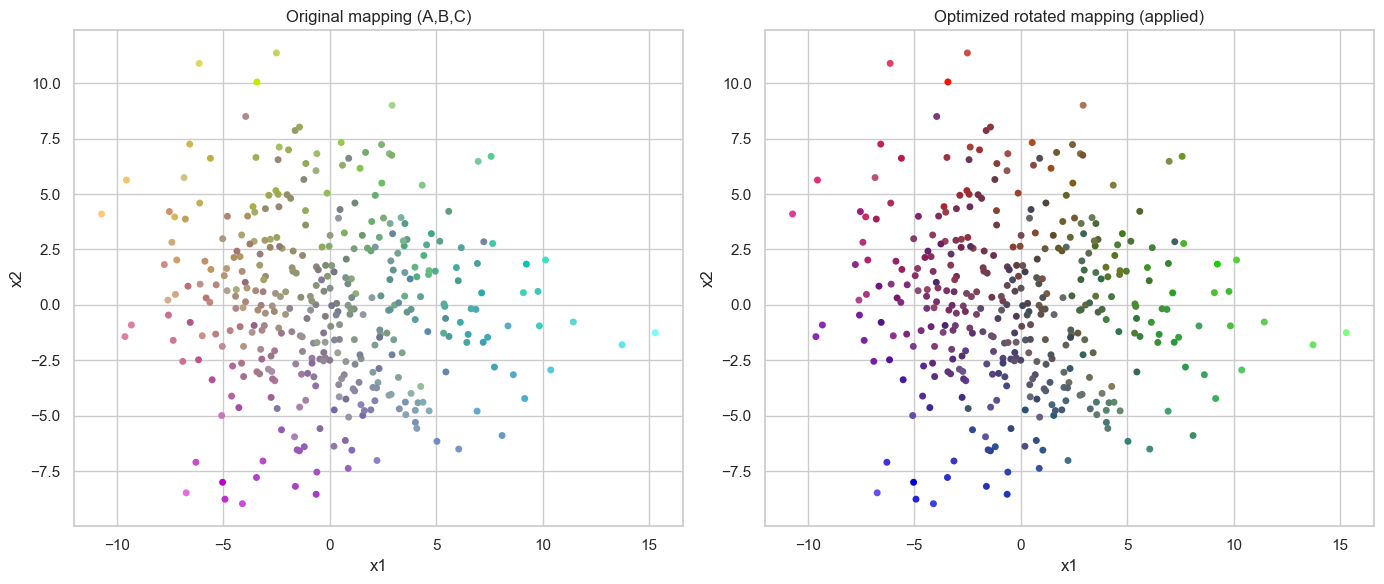

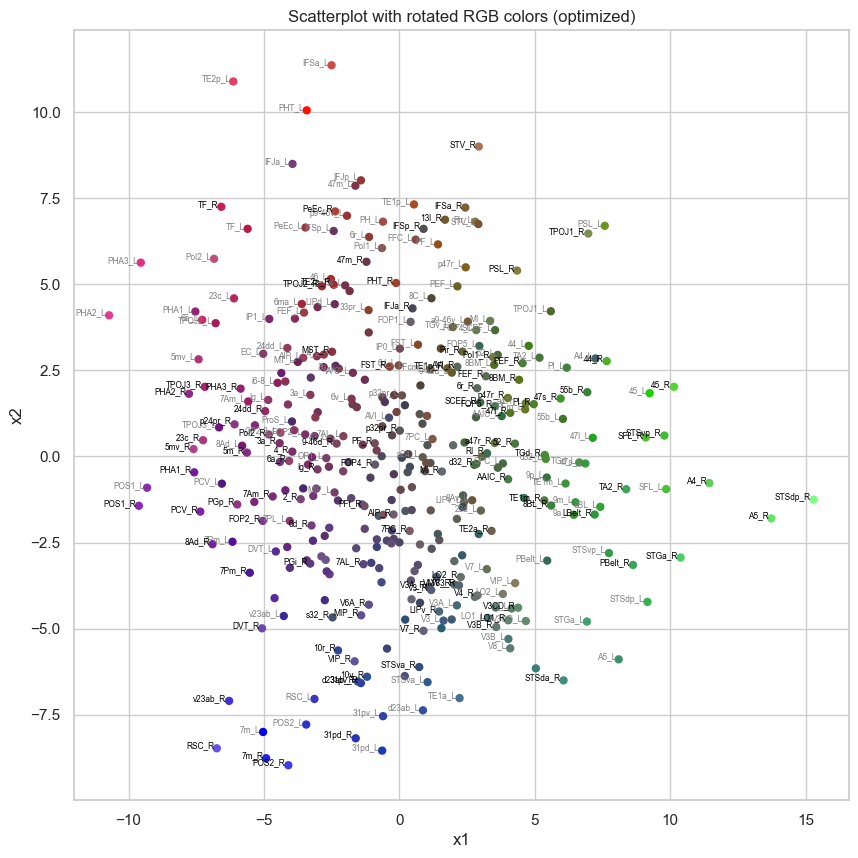

In [343]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import warnings

# Optional perceptual distance (recommended)
try:
    from skimage.color import rgb2lab
    _HAS_SKIMAGE = True
except Exception:
    _HAS_SKIMAGE = False
    warnings.warn("scikit-image not available — falling back to Euclidean RGB distances. "
                  "Install scikit-image for perceptual ΔE distances: pip install scikit-image")

# ----------------------------
# Your preprocessing (unchanged)
# ----------------------------
# df_plot = df_mds.loc[df_mds['LR']=='L'].copy()
df_plot = df_mds.copy()
# df_plot = df_mds.loc[df_mds['count_sig']>1].copy()
df_plot['group'] = 'other'

A = df_plot['160-L_45_ROI'].values
# A = df_plot['244-R_STSdp_ROI'].values
B = df_plot['125-L_7m_ROI'].values
C = df_plot['88-L_PHT_ROI'].values

def norm01(v):
    v = np.asarray(v, dtype=float)
    v = v - v.min()
    if v.max() != 0:
        v = v / v.max()
    return np.clip(v, 0, 1)

A, B, C = norm01(A), norm01(B), norm01(C)
colors = np.stack([A, B, C], axis=1)   # shape (n,3)
n = colors.shape[0]

# ----------------------------
# Rotation & objective helpers
# ----------------------------
def rotation_matrix_from_euler(angles):
    """ZYX Euler angles (alpha, beta, gamma) -> R = Rz(a) Ry(b) Rx(g)"""
    a, b, g = angles
    ca, sa = np.cos(a), np.sin(a)
    cb, sb = np.cos(b), np.sin(b)
    cg, sg = np.cos(g), np.sin(g)
    Rz = np.array([[ ca, -sa, 0],
                   [ sa,  ca, 0],
                   [  0,   0, 1]])
    Ry = np.array([[ cb, 0, sb],
                   [  0, 1,  0],
                   [-sb, 0, cb]])
    Rx = np.array([[1,   0,    0],
                   [0,  cg, -sg],
                   [0,  sg,  cg]])
    return Rz @ Ry @ Rx

def global_rescale_to_unit(rot):
    mn = rot.min()
    mx = rot.max()
    if mx - mn == 0:
        return np.clip(rot - mn, 0, 1)
    scaled = (rot - mn) / (mx - mn)
    return np.clip(scaled, 0, 1)

def color_distance_matrix_rgb(colors01):
    diffs = colors01[:, None, :] - colors01[None, :, :]
    dists = np.sqrt(np.sum(diffs**2, axis=-1))
    return dists

def color_distance_matrix_lab(colors01):
    # skimage.rgb2lab expects shape (M, N, 3) or (n,3) reshaped
    lab = rgb2lab(colors01.reshape(-1,1,3)).reshape(-1,3)
    diffs = lab[:, None, :] - lab[None, :, :]
    dists = np.sqrt(np.sum(diffs**2, axis=-1))
    return dists

def make_objective(colors_full, metric='mean', perceptual=True, subsample_idx=None):
    """Return objective function (neg score) that operates on a subset (if provided)."""
    if subsample_idx is None:
        colors_for_opt = colors_full
    else:
        colors_for_opt = colors_full[subsample_idx]

    def obj_fn(angles):
        R = rotation_matrix_from_euler(angles)
        rotated = colors_for_opt.dot(R.T)
        scaled = global_rescale_to_unit(rotated)
        if perceptual and _HAS_SKIMAGE:
            D = color_distance_matrix_lab(scaled)
        else:
            D = color_distance_matrix_rgb(scaled)
        iu = np.triu_indices_from(D, k=1)
        pair_dists = D[iu]
        if pair_dists.size == 0:
            score = 0.0
        else:
            if metric == 'mean':
                score = pair_dists.mean()
            elif metric == 'min':
                score = pair_dists.min()
            elif metric == 'median':
                score = np.median(pair_dists)
            else:
                raise ValueError("metric must be 'mean','min' or 'median'")
        return -float(score)   # minimize negative => maximize score
    return obj_fn

def optimize_rotation(colors_full, metric='mean', perceptual=True, n_restarts=8,
                      subsample_n=500, verbose=True, random_seed=1):
    rng = np.random.default_rng(random_seed)
    n = colors_full.shape[0]
    # choose subset indices for speed (if desired)
    if (subsample_n is not None) and (n > subsample_n):
        subsample_idx = rng.choice(n, size=subsample_n, replace=False)
    else:
        subsample_idx = None

    obj = make_objective(colors_full, metric=metric, perceptual=perceptual, subsample_idx=subsample_idx)

    best = None
    best_angles = None
    for i in range(n_restarts):
        x0 = np.random.uniform(-np.pi, np.pi, size=3)
        res = minimize(obj, x0, method='Nelder-Mead',
                       options={'maxiter':2000, 'disp': False})
        if verbose:
            print(f"restart {i}: success={res.success}, fun={res.fun:.6f}, nit={res.nit}")
        if (best is None) or (res.fun < best):
            best = res.fun
            best_angles = res.x

    if verbose:
        print("best objective (neg score) =", best, "=> best score =", -best)
    return best_angles

# ----------------------------
# Run optimization (on a subset if dataset large)
# ----------------------------
metric = 'mean'                 # 'mean' or 'min' or 'median'
perceptual = _HAS_SKIMAGE        # prefer Lab if available
best_angles = optimize_rotation(colors, metric=metric, perceptual=perceptual,
                                n_restarts=12, subsample_n=600, verbose=True, random_seed=2)

# Apply best rotation to the full dataset
R_best = rotation_matrix_from_euler(best_angles)
rotated_full = colors.dot(R_best.T)
colors_rot = global_rescale_to_unit(rotated_full)   # values in [0,1]

# Optionally convert to 0-255 ints for export:
colors_rot_255 = np.round(colors_rot * 255).astype(int)

# ----------------------------
# Visualize: side-by-side comparison
# ----------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
ax0, ax1 = axes

ax0.scatter(df_plot['x1'], df_plot['x2'], c=colors, s=25, edgecolors='none')
ax0.set_title('Original mapping (A,B,C)')
ax0.set_xlabel('x1'); ax0.set_ylabel('x2')

ax1.scatter(df_plot['x1'], df_plot['x2'], c=colors_rot, s=25, edgecolors='none')
ax1.set_title('Optimized rotated mapping (applied)')
ax1.set_xlabel('x1'); ax1.set_ylabel('x2')

plt.tight_layout()
plt.show()

# ----------------------------
# How to apply into your existing single-ax pipeline
# ----------------------------
fig, ax = plt.subplots(1,1, figsize=(10,10))

for _, row in df_plot.iterrows():
    if row['count_sig'] >= 3:
        x = row['x1'] - 0.1
        y = row['x2']
        label = str(row['label_new'] + '_' + row['LR'])
        font_color = 'gray' if row['LR'] == 'L' else 'black'
        ax.text(x, y, label, fontsize=6, ha='right', color=font_color)

# Use rotated colors instead of original colors
ax.scatter(df_plot['x1'], df_plot['x2'], color=colors_rot, s=25, edgecolor=None)
ax.set_title("Scatterplot with rotated RGB colors (optimized)")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
plt.show()


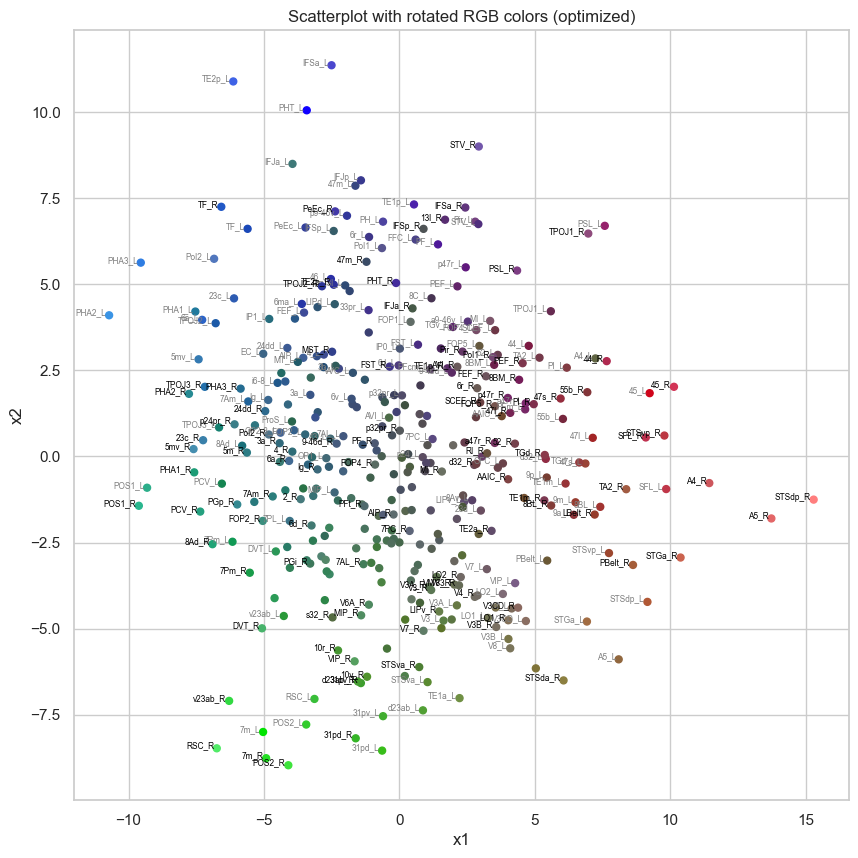

In [346]:
fig, ax = plt.subplots(1,1, figsize=(10,10))

for _, row in df_plot.iterrows():
    if row['count_sig'] >= 3:
        x = row['x1'] - 0.1
        y = row['x2']
        label = str(row['label_new'] + '_' + row['LR'])
        font_color = 'gray' if row['LR'] == 'L' else 'black'
        ax.text(x, y, label, fontsize=6, ha='right', color=font_color)

# Use rotated colors instead of original colors
ax.scatter(df_plot['x1'], df_plot['x2'], color=colors_rot[:,[1,2,0]], s=25, edgecolor=None)
ax.set_title("Scatterplot with rotated RGB colors (optimized)")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
plt.show()

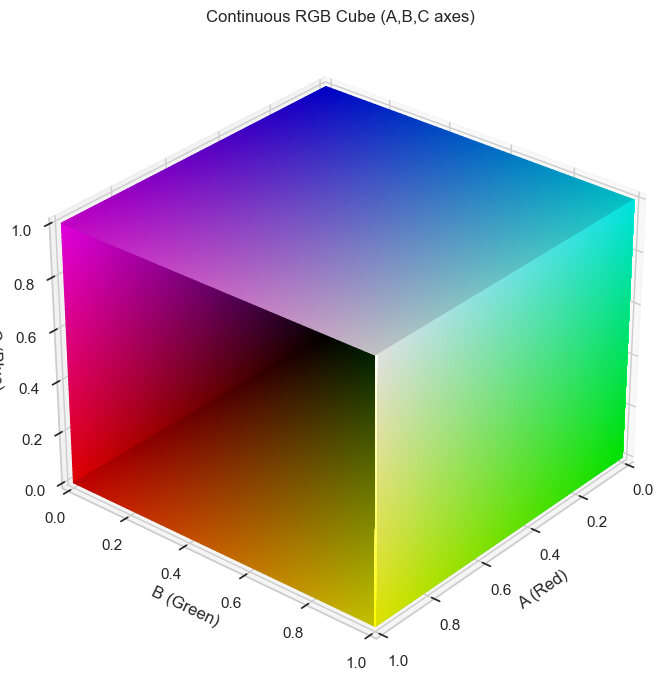

In [351]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

def show_color_cube_faces(res=50, elev=25, azim=35):
    """Draw a continuous RGB cube using colored faces."""
    # Axes for cube
    A = np.linspace(0, 1, res)
    B = np.linspace(0, 1, res)
    A, B = np.meshgrid(A, B)

    fig = plt.figure(figsize=(8, 7))
    ax = fig.add_subplot(111, projection='3d')

    # Plot 6 faces of the cube, each face colored by its (A,B,C)
    # Front (C=0)
    C = np.zeros_like(A)
    ax.plot_surface(A, B, C, facecolors=np.stack([A,B,C], -1), rstride=1, cstride=1)
    # Back (C=1)
    C = np.ones_like(A)
    ax.plot_surface(A, B, C, facecolors=np.stack([A,B,C], -1), rstride=1, cstride=1)
    # Bottom (B=0)
    B = np.zeros_like(A)
    C = np.linspace(0, 1, res)
    A, C = np.meshgrid(np.linspace(0, 1, res), np.linspace(0, 1, res))
    ax.plot_surface(A, B, C, facecolors=np.stack([A,B,C], -1), rstride=1, cstride=1)
    # Top (B=1)
    B = np.ones_like(A)
    ax.plot_surface(A, B, C, facecolors=np.stack([A,B,C], -1), rstride=1, cstride=1)
    # Left (A=0)
    A = np.zeros_like(B)
    ax.plot_surface(A, B, C, facecolors=np.stack([A,B,C], -1), rstride=1, cstride=1)
    # Right (A=1)
    A = np.ones_like(B)
    ax.plot_surface(A, B, C, facecolors=np.stack([A,B,C], -1), rstride=1, cstride=1)

    # Labels and style
    ax.set_xlabel("A (Red)")
    ax.set_ylabel("B (Green)")
    ax.set_zlabel("C (Blue)")
    ax.set_xlim(0,1); ax.set_ylim(0,1); ax.set_zlim(0,1)
    ax.view_init(elev=elev, azim=azim)
    ax.set_title("Continuous RGB Cube (A,B,C axes)")
    plt.tight_layout()
    plt.show()

# Example usage:
show_color_cube_faces(res=60, elev=30, azim=40)


In [349]:

def make_output_txt(df_output,path_txtOutput):
        
    with open(path_txtOutput, 'w') as f:
        for i,row in df_output.iterrows():
            line = row['label']
            f.write(line + '\n')  # Add newline character explicitly

            line = f"{row['idx']} {row['rgb']} {row['alpha']}"
            f.write(line + '\n')  # Add newline character explicitly

df_output = df_mds.copy()
df_output['alpha'] = '255'

# df_output['rgb'] = [
#     f"{255-int(round(a*255))} {255-int(round(b*255))} {255-int(round(c*255))}"
#     for c, a, b in colors_rot_255
# ]

df_output['rgb'] = [
    f"{a} {b} {c}"
    for a,b,c in colors_rot_255[:,[1,2,0]]
]

df_output = pd.merge(left = df_txt[['idx','label']],left_on='label',
         right = df_output[['label','rgb','count_sig','alpha']],right_on='label',how='left')

file = f'Fig_sameMDScolor4'
Dir_output = os.path.join(Dir_working,'workbench','distance_exploration')
path_txtOutput = os.path.join(Dir_output,f'{file}.txt')
img_output = os.path.join(Dir_output,f'{file}.dlabel.nii')
img_input = os.path.join(path_wb_atlas,'Q1-Q6_RelatedValidation210.CorticalAreas_dil_Final_Final_Areas_Group_Colors.32k_fs_LR.dlabel.nii')
make_output_txt(df_output,path_txtOutput)

cmd = f'{path_wb}\wb_command -cifti-label-import {img_input} {path_txtOutput} {img_output}'
subprocess.run(cmd, check=True)

CompletedProcess(args='Z:\\Software\\workbench\\bin_windows64\\wb_command -cifti-label-import Z:\\Software\\workbench\\atlas\\Q1-Q6_RelatedValidation210.CorticalAreas_dil_Final_Final_Areas_Group_Colors.32k_fs_LR.dlabel.nii Z:\\study\\phd\\project\\Semantics\\Dissemination\\table_figure\\workbench\\distance_exploration\\Fig_sameMDScolor4.txt Z:\\study\\phd\\project\\Semantics\\Dissemination\\table_figure\\workbench\\distance_exploration\\Fig_sameMDScolor4.dlabel.nii', returncode=0)

<Axes: xlabel='x1', ylabel='x2'>

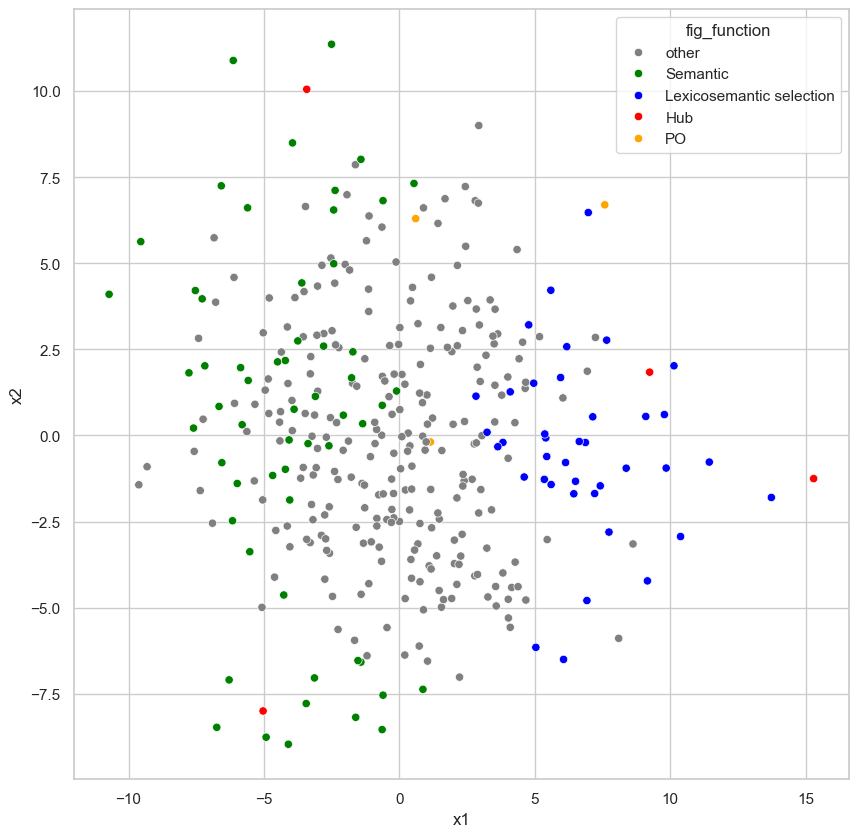

In [249]:
df_framework = pd.read_excel(os.path.join(Dir_working,'workbench','framework_exploration','table_framework_rule-distanceSig_RD.xlsx'))
df_framework['fig_function'].unique()
df_plot = pd.merge(left=df_mds,left_on='label',
         right=df_framework[['label','fig_function']],right_on='label',how='left')
df_plot.loc[df_plot['fig_function'].isna(),'fig_function'] = 'other'

palette_framework = {'other':'gray','Semantic':'green','Lexicosemantic selection':'blue','Hub':'red','PO':'orange'}
fig,ax = plt.subplots(1,1,figsize=(10,10))
sns.scatterplot(df_plot,x='x1',y='x2',ax=ax,hue='fig_function',palette=palette_framework)


Text(0.5, 1.0, 'Original MDS Projection')

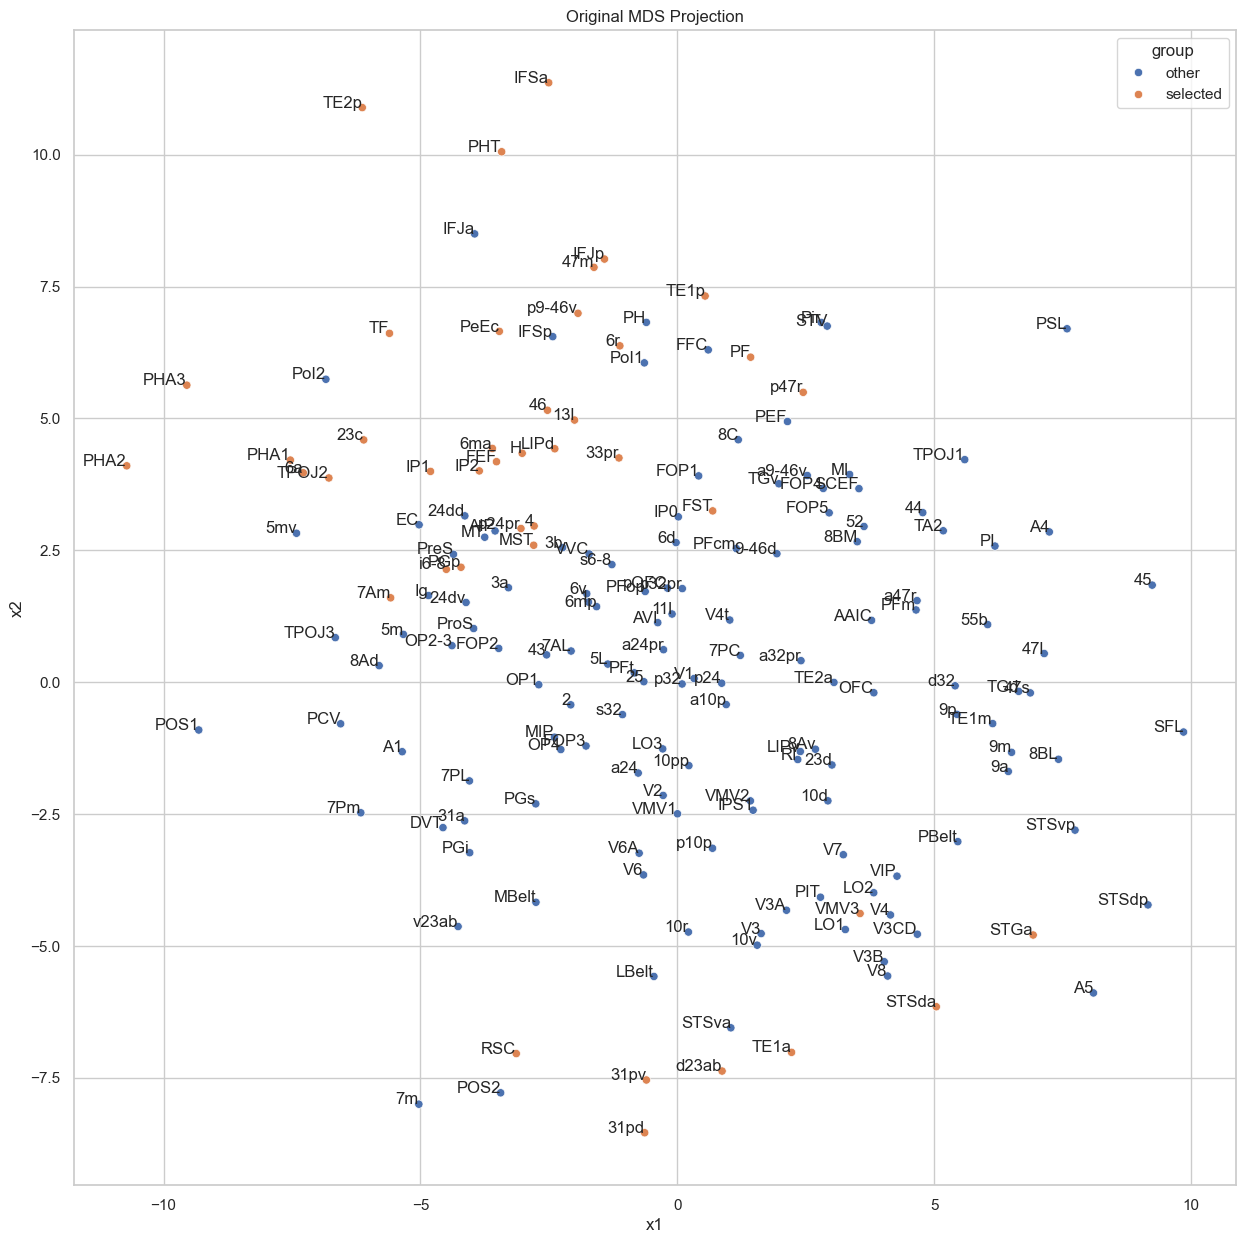

In [182]:
import seaborn as sns
### --- load seed ---
# roi = '160-L_45_ROI'
roi = '244-R_STSdp_ROI'
roi = '125-L_7m_ROI'
roi = '88-L_PHT_ROI'
df_raw = pd.read_csv(os.path.join(Dir_working,'workbench','distance_exploration',f'Fig_distance_exploration_{roi}_color1_sig.txt'),header=None)
df_raw.columns=['raw']
df = pd.DataFrame({'label':df_raw.iloc[::2]['raw'].values,
                   'raw':df_raw.loc[df_raw.index % 2 == 1,'raw'].values,})
df[['idx','R','G','B','alpha']] = df['raw'].str.split(' ',expand=True)
List_selected = df.loc[df['alpha']=='255','label']

### --- plot MDS ---

fig,ax = plt.subplots(1,1,figsize=(15,15))
df_plot = df_mds.loc[df_mds['LR']=='L'].copy()
df_plot['group'] = 'other'
df_plot.loc[df_plot['label'].isin(List_selected),'group'] = 'selected'

sns.scatterplot(df_plot,x='x1',y='x2',ax=ax,hue='group')

for i, row in df_plot.iterrows():
    x=row['x1']
    y=row['x2']
    i = row['label_new']
    ax.text(x, y, str(i), fontsize=12, ha='right')
ax.set_title("Original MDS Projection")

# df_plot = df_mds.loc[df_mds['LR']=='R'].copy()
# sns.scatterplot(df_plot,x='x1',y='x2',ax=ax)

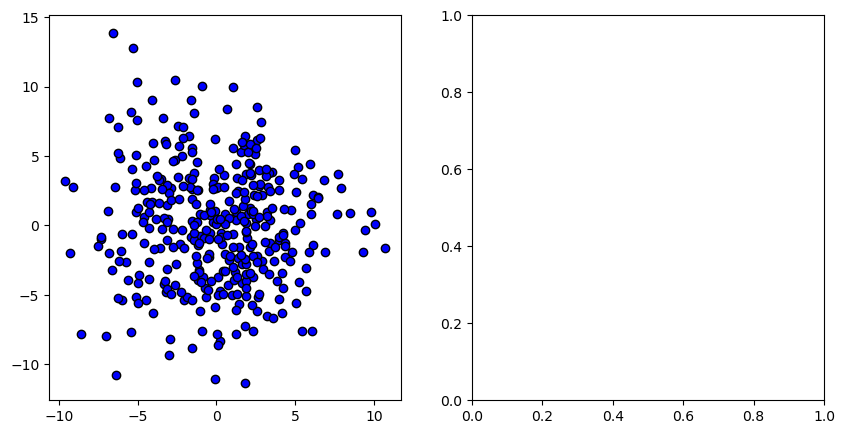

In [16]:

# Plot before and after rotation
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

# Original MDS
ax[0].scatter(X_mds[:, 0], X_mds[:, 1], color='blue', edgecolors='k')